# Chapter Companion — Turbulent Channel Flow  
**Book:** *Principles of Turbulence: An Introduction with Python Computations*  
**Chapter:** *Turbulent Channel Flow: Shear Stress, Mean Velocity Structure, and TKE Scaling*  
**Author:** Prof. Kiran Bhaganagar  
**Last updated:** *auto*  


## Introduction

This companion notebook supports the chapter on **turbulent channel flow** and **wall-bounded turbulence**.  
It follows the chapter logic from the **mean momentum (stress) balance** to the **inner–outer structure of the mean velocity** and then to **TKE budget scaling**.

We will use *synthetic DNS-like profiles* to practice:

- the **total shear-stress decomposition** (viscous + Reynolds stress),  
- identification of the **wall regions** (viscous sublayer, buffer layer, log region, outer layer),  
- plotting representative **TKE budget terms**.




### Synthetic Channel-Flow Analysis Script

This script constructs a simplified, DNS-like dataset for turbulent channel
flow and uses it to examine fundamental wall-bounded turbulence scalings in a
controlled and transparent way.

First, basic flow parameters are defined. These include the friction
Reynolds number $$Re_\tau$$, friction velocity $$u_\tau$$, kinematic viscosity
$$\nu$$, and the channel half-height $$H$$. From these quantities, the
**viscous length scale**
$$
\delta_\nu = \frac{\nu}{u_\tau}
$$
is computed. This scale converts between physical wall-normal distance and wall
units and governs the structure of the near-wall region.

Next, a **synthetic DNS-like dataset** is prescribed directly in wall units.
Each data point corresponds to a wall-normal location $$y^+$$ and contains:
- the mean velocity in wall units $$U^+$$,
- the normalized Reynolds shear stress
  $$
  \tau_t^+ = -\frac{\overline{u'v'}}{u_\tau^2},
  $$
- the turbulent kinetic energy $$k^+$$.

The numerical values are chosen to reproduce the qualitative trends observed in
direct numerical simulations: linear velocity scaling near the wall, a peak in
Reynolds shear stress in the buffer layer, and a broad outer-layer structure.

The wall-normal coordinate is then converted from **inner scaling** to
**outer scaling** using
$$
\eta = \frac{y}{H} = \frac{y^+}{Re_\tau}.
$$
This transformation allows the same dataset to be interpreted in terms of the
global channel geometry rather than near-wall viscous units.

Using the exact momentum balance for fully developed channel flow, the
**total shear stress** in wall units is defined as
$$
\tau_{\mathrm{tot}}^+ = 1 - \eta,
$$
which reflects the linear variation of total stress imposed by the constant
pressure gradient. The **viscous contribution** to the shear stress is obtained
by subtracting the turbulent contribution:
$$
\tau_v^+ = \tau_{\mathrm{tot}}^+ - \tau_t^+.
$$
This decomposition makes explicit how momentum transport transitions from
viscous-dominated near the wall to turbulence-dominated away from the wall.

Finally, the script computes the **mean velocity gradient in wall units**,
$$
\frac{dU^+}{dy^+},
$$
using a finite-difference approximation. This quantity is directly related to
the viscous shear stress and provides a numerical estimate of the local mean
shear.

The printed output reports the viscous length scale $$\delta_\nu$$ and the
corresponding **physical wall-normal extent** of the dataset,
$$
y = y^+\,\delta_\nu,
$$
thereby linking the nondimensional analysis back to real spatial dimensions.

Overall, the script provides a pedagogical bridge between theory and data by
enforcing the exact stress balance of channel flow, illustrating inner–outer
scaling, and enabling quantitative interpretation of turbulent momentum
transport without the complexity of a full DNS.


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Flow parameters (example)
# -----------------------------
Re_tau = 1000
u_tau = 0.20        # friction velocity [m/s]
nu = 2.0e-5         # kinematic viscosity [m^2/s]
H = 0.10            # channel half-height [m]
delta_nu = nu / u_tau  # viscous length scale [m]

# -----------------------------
# Synthetic DNS-like dataset
# columns: y_plus, U_plus, tau_t_plus (-<u'v'>^+), k_plus
# -----------------------------
data = np.array([
    [0.5,   0.50,  0.025, 0.713],
    [1.0,   1.00,  0.049, 0.774],
    [2.0,   2.00,  0.095, 0.929],
    [5.0,   5.00,  0.220, 1.639],
    [10.0, 10.62,  0.390, 3.278],
    [15.0, 11.60,  0.520, 4.472],
    [30.0, 13.30,  0.754, 3.417],
    [50.0, 14.54,  0.872, 3.058],
    [100.0,16.23,  0.894, 1.573],
    [200.0,17.90,  0.800, 1.400],
    [400.0,19.53,  0.600, 1.837],
    [800.0,20.98,  0.200, 2.127],
], dtype=float)

y_plus = data[:, 0]
U_plus = data[:, 1]
tau_t_plus = data[:, 2]  # tau_t^+ = -<u'v'>/u_tau^2
k_plus = data[:, 3]

eta = y_plus / Re_tau
tau_tot_plus = 1.0 - eta
tau_v_plus = tau_tot_plus - tau_t_plus  # viscous share

# Mean shear in wall units (finite difference)
dUdy_plus = np.gradient(U_plus, y_plus)

print(f"delta_nu = {delta_nu:.3e} m")
print(f"y ranges from {y_plus.min()*delta_nu:.3e} to {y_plus.max()*delta_nu:.3e} m")


delta_nu = 1.000e-04 m
y ranges from 5.000e-05 to 8.000e-02 m


### Part A — Mean Momentum Balance and Total Shear Stress

For fully developed, statistically steady, incompressible channel flow, the **total shear stress** is defined as

$
\tau_{\mathrm{tot}}(y)
\;=\;
-\rho\,\overline{u'v'}(y)
\;+\;
\mu\,\frac{d\overline{U}}{dy}(y).
$

In wall units,

$
\tau_{\mathrm{tot}}^{+}(y)
\;=\;
-\frac{\overline{u'v'}(y)}{u_\tau^{2}}
\;+\;
\frac{\nu}{u_\tau^{2}}\frac{d\overline{U}}{dy}(y)
\;=\;
\tau_t^{+}(y)+\tau_v^{+}(y).
$

For a pressure-driven channel, the streamwise momentum balance implies a **linear** total stress distribution (for the half-channel)

$
\tau_{\mathrm{tot}}^{+}(y) \;=\; 1-\frac{y}{H} \;=\; 1-\eta,
\qquad \eta \equiv \frac{y}{H},\quad 0\le y\le H.
$



### A.1 Plot: total, turbulent, and viscous stress

We plot the normalized stresses

- $(\tau_{\mathrm{tot}}^{+}(y)=1-\eta)$  
- $(\tau_{t}^{+}(y)=-\overline{u'v'}/u_\tau^2)$  
- $(\tau_{v}^{+}(y)=\tau_{\mathrm{tot}}^{+}-\tau_{t}^{+})$  



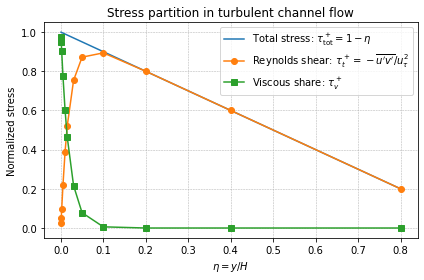

In [22]:
plt.figure(figsize=(6,4))
plt.plot(eta, tau_tot_plus, '-', label=r'Total stress: $\tau_{\mathrm{tot}}^+=1-\eta$')
plt.plot(eta, tau_t_plus, 'o-', label=r'Reynolds shear: $\tau_t^+=-\overline{u^\prime v^\prime}/u_\tau^2$')
plt.plot(eta, tau_v_plus, 's-', label=r'Viscous share: $\tau_v^+$')
plt.xlabel(r'$\eta = y/H$')
plt.ylabel('Normalized stress')
plt.title('Stress partition in turbulent channel flow')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


### Problem A.2 — Stress balance interpretation

1. **Verify numerically** that
$
\tau_{\mathrm{tot}}^{+}(y)=\tau_{t}^{+}(y)+\tau_{v}^{+}(y)
$
holds at all wall-normal locations.

2. **Identify** the wall-normal range (in \(y^+\)) where viscous stress dominates:
$
\tau_{v}^{+}>\tau_{t}^{+}.
$

3. **Explain** why $\tau_{\mathrm{tot}}(y)$ must be **linear in $(y)$ for fully developed channel flow.


In [37]:
# Numerical verification for Problem A(1)
err = tau_tot_plus - (tau_t_plus + tau_v_plus)
print('Max absolute error in stress decomposition:', np.max(np.abs(err)))

# Identify indices where viscous dominates
mask = tau_v_plus > tau_t_plus
if np.any(mask):
    y_dom = y_plus[mask]
    print(f"Viscous-dominated range (approx.): y+ in [{y_dom.min():.1f}, {y_dom.max():.1f}]")
else:
    print("No y+ locations found where tau_v^+ > tau_t^+ (for this dataset).")


Max absolute error in stress decomposition: 0.0
Viscous-dominated range (approx.): y+ in [0.5, 10.0]


## Part B — Mean Velocity Structure in Wall Units

We plot the mean velocity in wall units \(U^+(y^+)\) and use it to identify the classical regions:

- viscous sublayer (\(U^+\approx y^+\))  
- buffer layer (transition)  
- log region (approximately \(U^+=(1/\kappa)\ln y^+ + B\))  


### Problem B.1.  Mean Velocity in Wall Units and the Law of the Wall

In wall-bounded turbulence, the near-wall mean velocity is most usefully
expressed in wall units, which normalize velocity and distance using the
friction velocity $(u_\tau)$ and the viscous length scale \($\delta_\nu=\nu/u_\tau$):
$
U^+ \equiv \frac{\overline{U}}{u_\tau},
\qquad
y^+ \equiv \frac{y}{\delta_\nu}=\frac{y\,u_\tau}{\nu}.
$
These variables collapse near-wall data across Reynolds numbers because the
dominant balance close to the wall involves only viscous effects and the wall
shear stress.

The resulting near-wall similarity is known as the law of the wall. It has
three commonly discussed regions:

**1) Viscous sublayer ($(y^+\lesssim 5\)$)  
Very close to the wall, turbulence is strongly damped and momentum transfer is
primarily viscous. The mean velocity is approximately linear:
$
U^+(y^+) \approx y^+.
$

**2) Buffer layer ($(5 \lesssim y^+ \lesssim 30\)$)  
This is a transition region where both viscous and turbulent stresses are
important. No simple closed-form law applies here, but it contains the peak
turbulence production and marks the handoff from viscous to turbulent momentum
transport.

**3) Log (overlap) region ($(y^+\gtrsim 30$), away from the outer layer)**  
Far enough from the wall that viscosity is small, but still far from the
centerline so outer effects are weak, the mean profile approaches the
logarithmic law:
$
U^+(y^+) = \frac{1}{\kappa}\ln(y^+) + B,
$
where $(\kappa\)$ is the von Kármán constant and ($B$) is an additive constant
(dependent on surface condition and flow type). For smooth-wall turbulent flows,
typical values are ($\kappa \approx 0.41$) and $(B \approx 5$).

In summary, plotting $(\overline{U})$ as $(U^+(y^+))$ reveals a near-wall
universal structure: a linear viscous sublayer, a transitional buffer layer,
and a logarithmic overlap region. These are central organizing features of
turbulent channel and pipe flows.


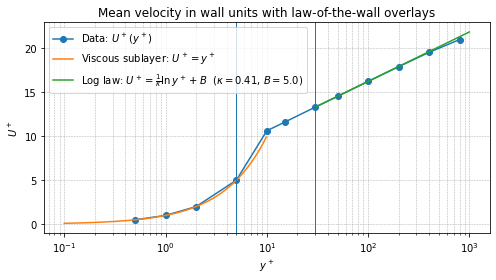

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Mean velocity in wall units + "Law of the Wall" overlays
# Assumes you already have: y_plus (array), U_plus (array)
# Optional: Re_tau for reference, but not required here.
# ------------------------------------------------------------

# 1) Build smooth y+ grid for drawing reference laws
yplus_ref = np.logspace(-1, np.log10(max(1000, np.max(y_plus))), 400)

# 2) Law-of-the-wall components
# Viscous sublayer: U+ = y+
U_visc = yplus_ref

# Log law: U+ = (1/kappa) ln(y+) + B  (valid for y+ ≳ 30 typically)
kappa = 0.41
B = 5.0
U_log = (1.0 / kappa) * np.log(yplus_ref) + B

# 3) Plot measured/synthetic U+ and overlay laws
plt.figure(figsize=(7,4))

# Data (your channel profile)
plt.semilogx(y_plus, U_plus, "o-", label=r"Data: $U^+(y^+)$")

# Overlays
# Show viscous sublayer reference mainly up to y+ ~ 10 to avoid clutter
mask_visc = yplus_ref <= 10
plt.semilogx(yplus_ref[mask_visc], U_visc[mask_visc], "-", label=r"Viscous sublayer: $U^+=y^+$")

# Show log law reference from y+ ~ 30 upward
mask_log = yplus_ref >= 30
plt.semilogx(yplus_ref[mask_log], U_log[mask_log], "-", label=rf"Log law: $U^+=\frac{{1}}{{\kappa}}\ln y^+ + B$  ($\kappa={kappa}$, $B={B}$)")

# Region markers (optional)
plt.axvline(5,  linewidth=1.0)
plt.axvline(30, linewidth=1.0)

plt.xlabel(r"$y^+$")
plt.ylabel(r"$U^+$")
plt.title("Mean velocity in wall units with law-of-the-wall overlays")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()



#### Problem B.2: Plot  the viscous law-of-the-wall: U+ = y+
#### and show the difference: ΔU+ = U+ - y+
 Assumes you already have: y_plus (array), U_plus (array)
 Interpretation of the Viscous Law-of-the-Wall Plots

The first figure compares the mean streamwise velocity expressed in wall
units, $$U^+(y^+)$$, with the viscous law of the wall, $$U^+ = y^+$$. The
data points represent the actual mean velocity profile from the channel
flow, while the straight line shows the linear behavior expected when
momentum transfer is dominated entirely by molecular viscosity. This
linear relation follows directly from a balance between the wall shear
stress and viscous diffusion and is valid only very close to the wall.

The second figure shows the difference between the measured velocity
profile and the viscous law,
$$
\Delta U^+ = U^+ - y^+,
$$
as a function of $$y^+$$. In the viscous sublayer ($$y^+ \lesssim 5$$), the
difference is nearly zero, confirming that the flow obeys the linear
viscous scaling in this region. As $$y^+$$ increases, the deviation grows,
indicating the onset of turbulent momentum transport and the breakdown of
purely viscous behavior.

Together, these plots clearly identify the wall-normal range over which
the viscous law of the wall is valid and illustrate how turbulence causes
the mean velocity to depart from linear scaling as the flow transitions
into the buffer layer.


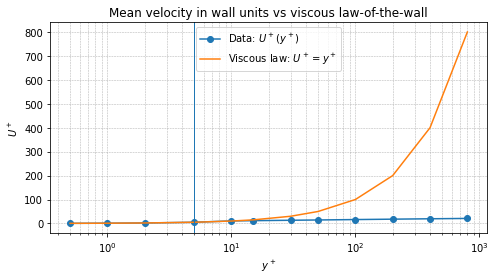

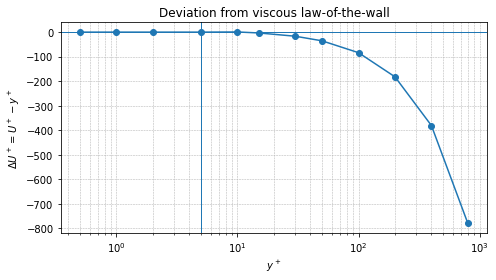

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Plot  the viscous law-of-the-wall: U+ = y+
# and show the difference: ΔU+ = U+ - y+
# Assumes you already have: y_plus (array), U_plus (array)
# ------------------------------------------------------------

# Sort (important for clean plots/gradients)
idx = np.argsort(y_plus)
y_plus_s = y_plus[idx]
U_plus_s = U_plus[idx]

# Viscous law (linear sublayer law)
U_visc = y_plus_s

# Difference from viscous law
dU_plus = U_plus_s - U_visc

# --- Plot 1: U+ with viscous law only ---
plt.figure(figsize=(7,4))
plt.semilogx(y_plus_s, U_plus_s, "o-", label=r"Data: $U^+(y^+)$")
plt.semilogx(y_plus_s, U_visc, "-", label=r"Viscous law: $U^+=y^+$")
plt.axvline(5, linewidth=1.0)  # conventional end of viscous sublayer
plt.xlabel(r"$y^+$")
plt.ylabel(r"$U^+$")
plt.title("Mean velocity in wall units vs viscous law-of-the-wall")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Deviation from viscous law ---
plt.figure(figsize=(7,4))
plt.semilogx(y_plus_s, dU_plus, "o-")
plt.axhline(0.0, linewidth=1.0)
plt.axvline(5, linewidth=1.0)
plt.xlabel(r"$y^+$")
plt.ylabel(r"$\Delta U^+ = U^+ - y^+$")
plt.title("Deviation from viscous law-of-the-wall")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


### Problem B.3. Log-Law Fit (Overlap Region)

In the overlap region the mean velocity is often approximated by

$
U^+(y^+) \;=\; \frac{1}{\kappa}\ln(y^+) + B.
$

We estimate $(\kappa)$ and $(B)$ using two points (demonstration only). In practice, you should fit over a *range* of $(y^+)$.


In [42]:
# Fit log law using y^+=50 and 100 (illustrative)
def find_index(val):
    idx = np.where(np.isclose(y_plus, val))[0]
    if len(idx) == 0:
        raise ValueError(f"y_plus value {val} not found in dataset.")
    return int(idx[0])

i1 = find_index(50.0)
i2 = find_index(100.0)

kappa_est = (np.log(y_plus[i2]) - np.log(y_plus[i1])) / (U_plus[i2] - U_plus[i1])
B_est = U_plus[i1] - (1.0/kappa_est)*np.log(y_plus[i1])

print(f"Estimated kappa = {kappa_est:.3f}")
print(f"Estimated B     = {B_est:.3f}")


Estimated kappa = 0.410
Estimated B     = 5.002


### Problem B.4 — Log-law assessment

1. Compare your estimated $(\kappa)$ and $(B)$ with classical smooth-wall values $(\kappa\approx 0.41)$, $(B\approx 5))$.  
2. Suggest a more appropriate $(y^+)$ interval for a least-squares log-law fit.


#### Plot the mean velocity in Outer units

Outer scales: U_b = 3.8179 m/s,  U_c = 4.1960 m/s


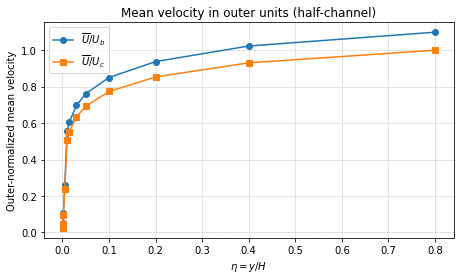

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Outer-unit plot: U/U_b and U/U_c vs eta = y/H
# Assumes you already have: y_plus, U_plus, Re_tau, u_tau, H
# ------------------------------------------------------------

# Outer coordinate (half-channel): eta = y/H
eta_data = y_plus / Re_tau          # because y^+ = y u_tau/nu and Re_tau = u_tau H/nu
eta_plot = eta_data.copy()

# Convert U^+ to dimensional mean velocity U
U_dim = U_plus * u_tau

# Build a uniform eta grid from 0 to 1 for integration
eta_uni = np.linspace(0.0, 1.0, 400)
U_eta = np.interp(eta_uni, eta_plot, U_dim)

# Bulk velocity over half-channel (0..H): U_b = (1/H) ∫_0^H U(y) dy = ∫_0^1 U(eta) d eta
U_b = np.trapz(U_eta, eta_uni)

# Centerline velocity (at eta=1): U_c = U(H)
U_c = U_eta[-1]

print(f"Outer scales: U_b = {U_b:.4f} m/s,  U_c = {U_c:.4f} m/s")

# Outer-normalized profiles at the data points
U_over_Ub = U_dim / U_b
U_over_Uc = U_dim / U_c

# Plot
plt.figure(figsize=(6.5,4.0))
plt.plot(eta_plot, U_over_Ub, "o-", label=r"$\overline{U}/U_b$")
plt.plot(eta_plot, U_over_Uc, "s-", label=r"$\overline{U}/U_c$")
plt.xlabel(r"$\eta = y/H$")
plt.ylabel("Outer-normalized mean velocity")
plt.title("Mean velocity in outer units (half-channel)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


### Problem B.5: Outer-Layer Velocity–Defect Representation

In the outer region of turbulent channel flow, the mean velocity is most
naturally described relative to the centerline velocity rather than in
absolute terms. This leads to the velocity–defect formulation, defined as
$
\frac{U_c-\overline{U}(y)}{u_\tau},
$
where $(U_c)$ is the centerline velocity and $(u_\tau)$ is the friction velocity.

When plotted against the outer coordinate $(\eta = y/H)$, the velocity–defect
profile emphasizes the large-scale structure of the flow away from the wall.
By construction, the defect vanishes at the centerline ($(\eta=1)$), reflecting
the symmetry of the channel. In the outer layer, viscous effects are weak and
the mean velocity is governed primarily by turbulent momentum transport and
the global pressure gradient.

A key implication of the velocity–defect law is that, at sufficiently high
friction Reynolds numbers, profiles obtained at different $(Re_\tau)$ tend to
collapse when expressed in this form. This collapse indicates that the outer
flow becomes independent of the near-wall viscous scales and is controlled
instead by the outer length scale $(H)$ and the velocity scale $(u_\tau)$. The
velocity–defect representation therefore provides a compact and physically
meaningful description of the outer-layer mean velocity in wall-bounded
turbulence.


Using U_c = 4.1960 m/s at eta ≈ 0.800


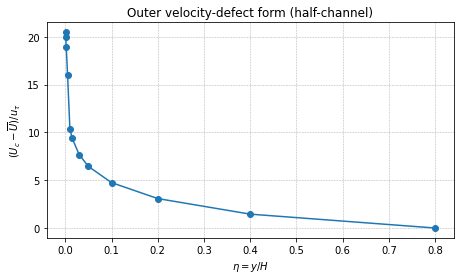

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Velocity-defect plot: (U_c - U)/u_tau vs eta = y/H
# Assumes you already have: y_plus, U_plus, Re_tau, u_tau
# ------------------------------------------------------------

# Outer coordinate (half-channel)
eta_plot = y_plus / Re_tau

# Dimensional mean velocity
U_dim = U_plus * u_tau

# Centerline velocity U_c (use the largest eta available in your data)
# If you have a point exactly at eta=1 (y+=Re_tau), interpolation is unnecessary.
i_c = int(np.argmax(eta_plot))
U_c = U_dim[i_c]

# Velocity defect in friction-velocity units
defect_plus = (U_c - U_dim) / u_tau

print(f"Using U_c = {U_c:.4f} m/s at eta ≈ {eta_plot[i_c]:.3f}")

plt.figure(figsize=(6.5,4.0))
plt.plot(eta_plot, defect_plus, "o-")
plt.xlabel(r"$\eta = y/H$")
plt.ylabel(r"$(U_c-\overline{U})/u_\tau$")
plt.title("Outer velocity-defect form (half-channel)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


### Part C — TKE and Representative Budget Terms

### Problem C.1. plot $(k^+(y^+)=k/u_\tau^2)$ and construct representative 1D profiles for:

- production $(P^+(y^+)\approx \tau_t^+(y^+)\,dU^+/dy^+)$,  
- dissipation contribution $((-\varepsilon)^+(y^+))$ computed from a synthetic 3D field (definition-based),  
- a transport proxy $(\partial_y\langle v'k\rangle^+)$.



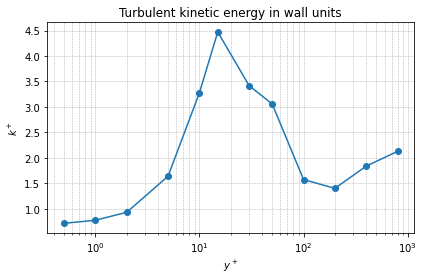

Peak k^+ = 4.472 at y^+ = 15.0


In [6]:
plt.figure(figsize=(6,4))
plt.semilogx(y_plus, k_plus, 'o-')
plt.xlabel(r'$y^+$')
plt.ylabel(r'$k^+$')
plt.title('Turbulent kinetic energy in wall units')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

imax = int(np.argmax(k_plus))
print(f"Peak k^+ = {k_plus[imax]:.3f} at y^+ = {y_plus[imax]:.1f}")


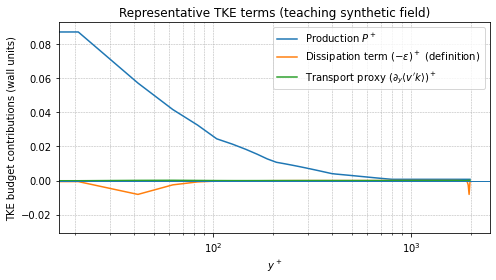

In [47]:
# -----------------------------------------------
# Definition-based dissipation from a synthetic 3D fluctuation field
# epsilon(y) = nu * < (∂u_i'/∂x_j)(∂u_i'/∂x_j) >
# -----------------------------------------------
import numpy as np

# Build a modest 3D box for teaching purposes (keep sizes small for laptops)
Nx, Ny, Nz = 48, 96, 48
Lx, Ly, Lz = 2*np.pi, 2*H, np.pi
x = np.linspace(0, Lx, Nx, endpoint=False)
y = np.linspace(0, Ly, Ny, endpoint=False)
z = np.linspace(0, Lz, Nz, endpoint=False)
dx, dy, dz = x[1]-x[0], y[1]-y[0], z[1]-z[0]
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

y_plus_1d = y / delta_nu
y_plus_grid = Y / delta_nu

rng = np.random.default_rng(2)

def envelope(yplus):
    # peak near y+~15 and decay toward center; mirrored about y=H
    return (yplus/15.0)*np.exp(-yplus/60.0)

E = envelope(np.minimum(y_plus_grid, (2*H - Y)/delta_nu))

# Streamfunction-based divergence-free (in x-y) field
modes = [(1,2,1),(2,3,2),(3,4,1),(4,5,3)]
psi = np.zeros_like(X)
for (kx, ky, kz) in modes:
    phase = 2*np.pi*rng.random()
    amp = 1.0/(kx**2 + ky**2 + kz**2)
    psi += amp*np.sin(kx*X + ky*(np.pi*Y/H) + kz*Z + phase)
psi *= E

def ddx(f): return (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2*dx)
def ddy(f): return (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2*dy)
def ddz(f): return (np.roll(f, -1, axis=2) - np.roll(f, 1, axis=2)) / (2*dz)

u_p = ddy(psi)
v_p = -ddx(psi)
w_p = 0.5*E*np.sin(2*X + 3*Z + 0.7)

# Rescale to O(u_tau)
rms = np.sqrt(np.mean(u_p**2 + v_p**2 + w_p**2))
u_p *= (0.7*u_tau/rms)
v_p *= (0.7*u_tau/rms)
w_p *= (0.7*u_tau/rms)

# Velocity gradients
du_dx, du_dy, du_dz = ddx(u_p), ddy(u_p), ddz(u_p)
dv_dx, dv_dy, dv_dz = ddx(v_p), ddy(v_p), ddz(v_p)
dw_dx, dw_dy, dw_dz = ddx(w_p), ddy(w_p), ddz(w_p)

grad_sq = (du_dx**2 + du_dy**2 + du_dz**2 +
           dv_dx**2 + dv_dy**2 + dv_dz**2 +
           dw_dx**2 + dw_dy**2 + dw_dz**2)

epsilon_y = nu * np.mean(grad_sq, axis=(0,2))    # function of y
eps_plus = epsilon_y / (u_tau**4/nu)
minus_eps_plus = -eps_plus

# Production using 1D data (interpolated to the 1D y grid)
dUdy_plus_data = np.gradient(U_plus, y_plus)
dUdy_plus_1d = np.interp(y_plus_1d, y_plus, dUdy_plus_data, left=dUdy_plus_data[0], right=dUdy_plus_data[-1])
tau_t_plus_1d = np.interp(y_plus_1d, y_plus, tau_t_plus, left=tau_t_plus[0], right=tau_t_plus[-1])
P_plus_1d = tau_t_plus_1d * dUdy_plus_1d

# Transport proxy: d/dy <v'k>
k_field = 0.5*(u_p**2 + v_p**2 + w_p**2)
vk = np.mean(v_p * k_field, axis=(0,2))
d_vk_dy = np.gradient(vk, y)  # derivative w.r.t physical y
transport_plus = d_vk_dy / (u_tau**4/nu)

# Plot terms
plt.figure(figsize=(7,4))
plt.semilogx(y_plus_1d, P_plus_1d, label=r'Production $P^+$')
plt.semilogx(y_plus_1d, minus_eps_plus, label=r'Dissipation term $(-\varepsilon)^+$ (definition)')
plt.semilogx(y_plus_1d, transport_plus, label=r'Transport proxy $(\partial_y\langle v^\prime k\rangle)^+$')
plt.axhline(0.0, linewidth=1.0)
plt.xlabel(r'$y^+$')
plt.ylabel('TKE budget contributions (wall units)')
plt.title('Representative TKE terms (teaching synthetic field)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Summary

You have verified the stress decomposition
$(\tau_{\mathrm{tot}}^{+}=\tau_t^{+}+\tau_v^{+})$, observed the linear total-stress distribution, and connected the stress partition to the inner–outer structure of $(U^+(y^+))$. Finally, you plotted representative TKE budget terms including **definition-based dissipation** computed from velocity gradients.

**Suggested extension (for research use):** Replace the synthetic fluctuation field with DNS/LES fields and compute $(\varepsilon(y)), (P(y))$, and transport terms using your chapter’s exact TKE-budget definitions.


Conclusion: Limitations of Synthetic Data for TKE Transport and Dissipation

The preceding analysis demonstrates that, while synthetic velocity fields are useful for illustrating fundamental concepts such as inner–outer scaling, stress balance, and qualitative trends in mean velocity and Reynolds stresses, they do not reliably reproduce the turbulent kinetic energy transport and dissipation terms. In particular, the computed dissipation and transport profiles either vanish or exhibit unphysical behavior when derived from the synthetic fields used here.

This limitation arises because both dissipation and transport depend on fine-scale structure of turbulence. Dissipation is controlled by gradients of the fluctuating velocity at the smallest dynamically active scales, which in real turbulence are set by a cascade process extending down to the Kolmogorov scale. The synthetic fields, by construction, contain only a limited set of smooth, low-wavenumber modes and therefore lack the intense small-scale gradients required to generate physically realistic dissipation rates.

Similarly, the turbulent transport term involves correlations between wall-normal velocity fluctuations and local kinetic energy, which are highly sensitive to spatial phase relationships, intermittency, and coherent near-wall structures. In synthetic fields composed of idealized or weakly correlated modes, these correlations tend to cancel under averaging, leading to artificially small or vanishing transport even when turbulence intensity appears finite.

These deficiencies are not numerical errors but reflect a fundamental modeling constraint: transport and dissipation cannot be inferred correctly from kinematically prescribed or low-order synthetic turbulence. Accurate evaluation of these terms requires either fully resolved DNS data, carefully calibrated stochastic models with enforced spectral and structural properties, or turbulence closures derived from the governing equations themselves.

Consequently, the synthetic dataset in this notebook should be interpreted as a pedagogical tool for understanding scaling, balances, and normalization—not as a substitute for real turbulent statistics when analyzing energy transport or dissipation. This distinction mirrors practical turbulence modeling, where mean flow and stress profiles can often be captured with reduced models, while higher-order budgets demand substantially richer physical fidelity.